In [12]:
# imports 
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt


In [13]:
# Download MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())


In [14]:
# get images of zeros and ones from the mnist dataset (digits 0 and 1 only)
all_images = [img for img in train_dataset if img[1] == 0]

In [15]:
# from here on out, we will deal with the flattened images only (vectors)
all_vectors = []
all_labels = []
for img, label in all_images:
    flattened = img.squeeze().numpy().flatten()
    all_vectors.append(flattened)
    all_labels.append(label)

# stack vectors into a matrix
all_matrix = np.array(all_vectors)

# double check that the values are between 0 and 1
all_matrix = np.clip(all_matrix, 0.0, 1.0)

# scale from [0, 1] to [-1, 1] to match ddpm paper
all_matrix = 2.0 * all_matrix - 1.0

# convert labels to numpy array for easy indexing
all_labels = np.array(all_labels)

# Keep zero_matrix variable name for backward compatibility with existing code
# but now it contains all digits
zero_matrix = all_matrix


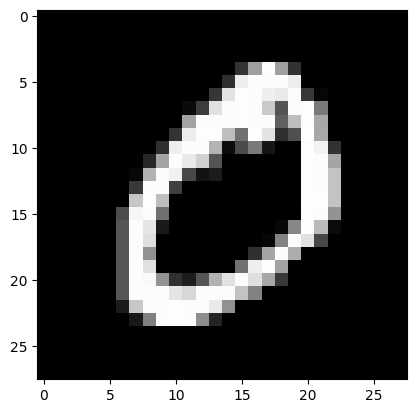

In [16]:
# im show an column in the zero matrix 
im = zero_matrix[0].reshape(28, 28)
# Convert from [-1, 1] to [0, 1] for visualization
im_viz = (im + 1.0) / 2.0
plt.imshow(im_viz, cmap='gray', vmin=0, vmax=1)
plt.show()



In [17]:
T = 1000

# precompute the alpha and beta coefficients for all the time steps
beta_dict = {}
alpha_dict = {}
for t in range(T + 1):  # 0 to T
    # in ddpm paper, beta is linearly interpoled from 10^-4 to 0.02
    beta_val = 10**-4 + (0.02 - 10**-4) * t / T
    alpha_val = 1 - beta_val
    beta_dict[t] = beta_val
    alpha_dict[t] = alpha_val

# Precompute alpha_bar_t for all timesteps
# alpha_bar_t(t) = product of alpha_t(0) * alpha_t(1) * ... * alpha_t(t-1)
alpha_bar_dict = {}
alpha_bar_dict[0] = 1.0  # explicit define t=0, product over empty range is 1
alpha_bar_cumprod = 1.0
for t in range(1, T + 1):  # 1 to T
    alpha_bar_cumprod *= alpha_dict[t - 1]  # Multiply by alpha_t(t-1)
    alpha_bar_dict[t] = alpha_bar_cumprod

# optional: precompute & store the sqrts of the coefs as well
sqrt_alpha_bar_dict = {t: np.sqrt(alpha_bar_dict[t]) for t in range(T + 1)}
sqrt_one_minus_alpha_bar_dict = {t: np.sqrt(1 - alpha_bar_dict[t]) for t in range(T + 1)}
sqrt_alpha_dict = {t: np.sqrt(alpha_dict[t]) for t in range(T + 1)}

# helper functions to access the precomputed values
def beta_t(t):
    t_int = int(t)
    return beta_dict[t_int]

def alpha_t(t):
    t_int = int(t)
    return alpha_dict[t_int]

def alpha_bar_t(t):
    t_int = int(t)
    return alpha_bar_dict[t_int]

In [18]:
# ---- timestep embedding ----
def sinusoidal_embedding(t, dim: int):
    """
    t: (B,) or (B,1) in [0,1]
    returns: (B, dim)
    """
    if t.dim() == 1:
        t = t.unsqueeze(1)  # (B,1)

    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device, dtype=t.dtype) / max(half - 1, 1)
    )  # (half,)
    angles = t * freqs.unsqueeze(0)  # (B,half)
    emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)  # (B,2*half)

    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


# ---- digit embedding (learnable MLP) ----
class DigitEmbedding(nn.Module):
    """
    Learnable MLP embedding for digit labels (0-1).
    """
    def __init__(self, num_classes=2, embedding_dim=64, hidden_dim=128):
        super().__init__()
        self.num_classes = num_classes
        self.embedding = nn.Embedding(num_classes, embedding_dim)
        # MLP: embedding -> hidden -> embedding_dim
        self.mlp = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, embedding_dim)
        )
        
    def forward(self, labels):
        """
        labels: (B,) tensor of digit labels (0 or 1)
        returns: (B, embedding_dim)
        """
        emb = self.embedding(labels)  # (B, embedding_dim)
        return self.mlp(emb)  # (B, embedding_dim)


# ---- conv block with normalization and time+digit conditioning ----
class TimeNormBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, kernel_size=3, stride=1, padding=1, transpose=False):
        super().__init__()
        conv_cls = nn.ConvTranspose2d if transpose else nn.Conv2d
        self.conv = conv_cls(in_ch, out_ch, kernel_size, stride=stride, padding=padding)
        self.norm = nn.GroupNorm(8 if out_ch >= 8 else 1, out_ch)
        # Project combined time+digit embedding to out_ch
        self.cond_proj = nn.Linear(time_dim, out_ch)
        
    def forward(self, x, combined_emb):
        """
        x: (B, C, H, W)
        combined_emb: (B, time_dim) - combined time + digit embedding
        """
        h = self.conv(x) + self.cond_proj(combined_emb).unsqueeze(-1).unsqueeze(-1)
        return F.silu(self.norm(h))


# ---- basic conv block with time conditioning ----


class TinyUNetMNIST(nn.Module):
    """
    Simple U-Net for MNIST diffusion (ε prediction) with 2 encoder and 2 decoder layers.
    All layers include normalization and combined time+digit embedding.
    """
    def __init__(self, input_dim=784, base_ch=32, time_dim=64, digit_embed_dim=64):
        super().__init__()
        self.input_dim = input_dim
        self.img_size = int(math.sqrt(input_dim))
        assert self.img_size * self.img_size == input_dim, "input_dim must be perfect square"

        self.time_dim = time_dim
        self.digit_embed_dim = digit_embed_dim
        
        # Digit embedding module (2 classes: 0 and 1)
        self.digit_embedding = DigitEmbedding(num_classes=2, embedding_dim=digit_embed_dim)
        
        # Project time and digit embeddings to same dimension, then combine
        # We'll combine them by adding, so both need to be time_dim
        self.time_proj = nn.Identity()  # time_dim stays the same
        self.digit_proj = nn.Linear(digit_embed_dim, time_dim)  # project digit to time_dim
        
        # All blocks now use combined embeddings of size time_dim
        self.in_block = TimeNormBlock(1, base_ch, time_dim)
        self.enc1 = TimeNormBlock(base_ch, base_ch, time_dim)
        self.downsample1 = TimeNormBlock(base_ch, base_ch, time_dim, kernel_size=4, stride=2, padding=1)
        self.enc2 = TimeNormBlock(base_ch, base_ch * 2, time_dim)
        self.downsample2 = TimeNormBlock(base_ch * 2, base_ch * 2, time_dim, kernel_size=4, stride=2, padding=1)
        self.upsample2 = TimeNormBlock(base_ch * 2, base_ch * 2, time_dim, kernel_size=4, stride=2, padding=1, transpose=True)
        self.dec2 = TimeNormBlock(base_ch * 4, base_ch, time_dim)
        self.upsample1 = TimeNormBlock(base_ch, base_ch, time_dim, kernel_size=4, stride=2, padding=1, transpose=True)
        self.dec1 = TimeNormBlock(base_ch * 2, base_ch, time_dim)
        self.out_norm = nn.GroupNorm(8 if base_ch >= 8 else 1, base_ch)
        self.out_cond_proj = nn.Linear(time_dim, base_ch)
        self.out_conv = nn.Conv2d(base_ch, 1, 3, padding=1)

    def forward(self, x, t, digit_labels):
        """
        x: (B, 784) - flattened images
        t: (B,) - normalized timesteps [0, 1]
        digit_labels: (B,) - digit labels (0 or 1)
        """
        x = x.view(x.shape[0], 1, self.img_size, self.img_size)
        
        # Get time and digit embeddings
        t_emb = sinusoidal_embedding(t, self.time_dim)  # (B, time_dim)
        digit_emb = self.digit_embedding(digit_labels)  # (B, digit_embed_dim)
        digit_emb_proj = self.digit_proj(digit_emb)  # (B, time_dim)
        
        # Combine time and digit embeddings by addition
        combined_emb = t_emb + digit_emb_proj  # (B, time_dim)
        
        # Pass combined embedding through all layers
        h0 = self.in_block(x, combined_emb)
        h1 = self.enc1(h0, combined_emb)
        d1 = self.downsample1(h1, combined_emb)
        h2 = self.enc2(d1, combined_emb)
        d2 = self.downsample2(h2, combined_emb)
        
        u2 = self.upsample2(d2, combined_emb)
        u2 = torch.cat([u2, h2], dim=1)
        u2 = self.dec2(u2, combined_emb)
        u1 = self.upsample1(u2, combined_emb)
        u1 = torch.cat([u1, h1], dim=1)
        u1 = self.dec1(u1, combined_emb)
        
        out = self.out_norm(u1) + self.out_cond_proj(combined_emb).unsqueeze(-1).unsqueeze(-1)
        return self.out_conv(F.silu(out)).view(x.shape[0], -1)



# Initialize model and optimizer
device = torch.device("mps" if torch.cuda.is_available() else "cpu")
model = TinyUNetMNIST(input_dim=784).to(device)
model.train()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_iterations = 2000
batch_size = 64

for i in range(num_iterations):
    # sample a batch of random images
    img_indices = np.random.randint(0, len(all_matrix), size=batch_size)
    samples = all_matrix[img_indices].astype(np.float32)  # (batch_size, 784)
    labels = all_labels[img_indices]  # (batch_size,) - digit labels
    
    # sample a batch of random time steps
    t_batch = np.random.randint(1, T + 1, size=batch_size)  # (batch_size,)
    t_tensor = torch.tensor(t_batch/T, dtype=torch.float32, device=device)  # (batch_size,)
    
    # convert labels to tensor
    labels_tensor = torch.tensor(labels, dtype=torch.long, device=device)  # (batch_size,)
    
    # sample random noise for each batch
    epsilon = np.random.randn(batch_size, 784).astype(np.float32)  # (batch_size, 784)
    epsilon_tensor = torch.tensor(epsilon, dtype=torch.float32, device=device)  # (batch_size, 784)
    
    # access the precomputed coefficients for each timestep in the batch
    coef_1_batch = np.array([sqrt_alpha_bar_dict[t] for t in t_batch], dtype=np.float32)  # (batch_size,)
    coef_2_batch = np.array([sqrt_one_minus_alpha_bar_dict[t] for t in t_batch], dtype=np.float32)  # (batch_size,)
    
    # use the update expression in ddpm algo 1 to make xt: x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
    # we use np.newaxis to broadcast the coefs to the shape of the samples
    x_t = coef_1_batch[:, np.newaxis] * samples + coef_2_batch[:, np.newaxis] * epsilon  # (batch_size, 784)
    x_t_tensor = torch.tensor(x_t, dtype=torch.float32, device=device)  # (batch_size, 784)
    
    # predict noise (now with digit labels)
    noise_pred = model(x_t_tensor, t_tensor, labels_tensor)  # (batch_size, 784)
    
    # compute loss as mse
    loss = nn.functional.mse_loss(noise_pred, epsilon_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (i + 1) % 10 == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss.item():.4f}")

print("Training complete!")


Iteration 10/2000, Loss: 0.2809
Iteration 20/2000, Loss: 0.2067
Iteration 30/2000, Loss: 0.1435
Iteration 40/2000, Loss: 0.1218
Iteration 50/2000, Loss: 0.1114
Iteration 60/2000, Loss: 0.0832
Iteration 70/2000, Loss: 0.1132
Iteration 80/2000, Loss: 0.0702
Iteration 90/2000, Loss: 0.0860
Iteration 100/2000, Loss: 0.0783
Iteration 110/2000, Loss: 0.0674
Iteration 120/2000, Loss: 0.0627
Iteration 130/2000, Loss: 0.0850
Iteration 140/2000, Loss: 0.0884
Iteration 150/2000, Loss: 0.0810
Iteration 160/2000, Loss: 0.0502
Iteration 170/2000, Loss: 0.0385
Iteration 180/2000, Loss: 0.0625
Iteration 190/2000, Loss: 0.0433
Iteration 200/2000, Loss: 0.0588
Iteration 210/2000, Loss: 0.0651
Iteration 220/2000, Loss: 0.0548
Iteration 230/2000, Loss: 0.0482
Iteration 240/2000, Loss: 0.0639
Iteration 250/2000, Loss: 0.0357
Iteration 260/2000, Loss: 0.0483
Iteration 270/2000, Loss: 0.0680
Iteration 280/2000, Loss: 0.0701
Iteration 290/2000, Loss: 0.0530
Iteration 300/2000, Loss: 0.0502
Iteration 310/2000,

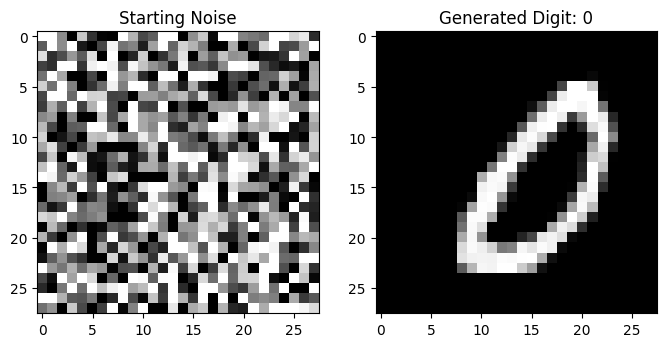

In [19]:
model.eval()

# Specify which digit to generate (0 or 1)
target_digit = 0  # Change this to 0 or 1 to generate different digits

# zero_matrix is (num_images, 784), so images are already flattened
# we can a standard random noise vector 
x_t = np.random.randn(784).astype(np.float32)  # (784,) - flattened vector
starting_noise = x_t.copy()  # (784,)

# Create digit label tensor for the target digit
digit_label = torch.tensor([target_digit], dtype=torch.long, device=device)  # (1,)

with torch.no_grad():
    for t in range(T, 0, -1):
        # Convert x_t to tensor (flattened: 784,)
        x_t_tensor = torch.tensor(x_t, dtype=torch.float32, device=device).unsqueeze(0)  # (1, 784)
        t_norm = t / T # normalize the time step to [0, 1]
        t_tensor = torch.tensor([t_norm], dtype=torch.float32, device=device)  # (1,)
        
        # predict noise (in flattened space) with digit label
        eps_pred = model(x_t_tensor, t_tensor, digit_label).squeeze(0).cpu().numpy().astype(np.float32)  # (784,)
        
        # access the precomputed coefficients
        bt = beta_dict[t]
        at = alpha_dict[t]
        abar = alpha_bar_dict[t]
        sqrt_at = sqrt_alpha_dict[t]
        sqrt_one_minus_abar = sqrt_one_minus_alpha_bar_dict[t]
        
        # ddpm reverse step: x_{t-1} = (1/sqrt(alpha_t)) * (x_t - (beta_t/sqrt(1-alpha_bar_t)) * eps_pred)
        mu = (1.0 / sqrt_at) * (x_t - (bt / sqrt_one_minus_abar) * eps_pred)  # (784,) - flattened
        
        if t > 1:
            # stochastic DDPM sampling: add noise
            z = np.random.randn(784).astype(np.float32)  # (784,) - flattened vector
            sigma = np.sqrt(bt)
            x_t = mu + sigma * z  # (784,) - flattened
        else:
            # in the last step don't add noise
            x_t = mu  # (784,) - flattened

# rehsape and transform for visualization
denoised_image = x_t.reshape(28, 28)
starting_noise_img = starting_noise.reshape(28, 28)
denoised_image_viz = (denoised_image + 1.0) / 2.0
starting_noise_img_viz = (starting_noise_img + 1.0) / 2.0

# Visualize the result
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(starting_noise_img_viz, cmap='gray', vmin=0, vmax=1)
plt.title('Starting Noise')
plt.subplot(1, 2, 2)
plt.imshow(denoised_image_viz, cmap='gray', vmin=0, vmax=1)
plt.title(f'Generated Digit: {target_digit}')
plt.show()



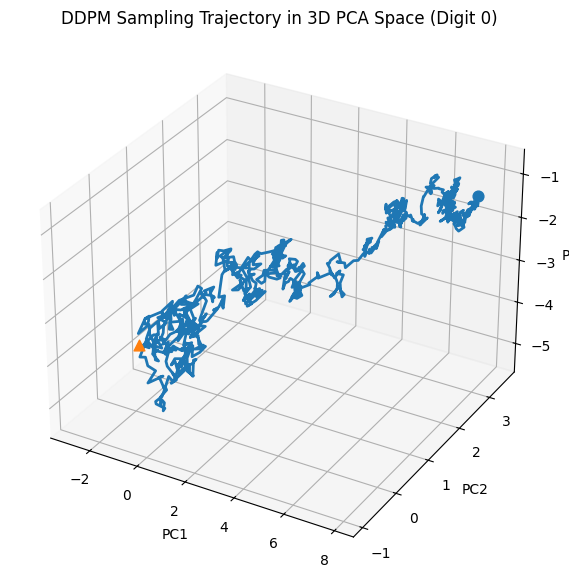

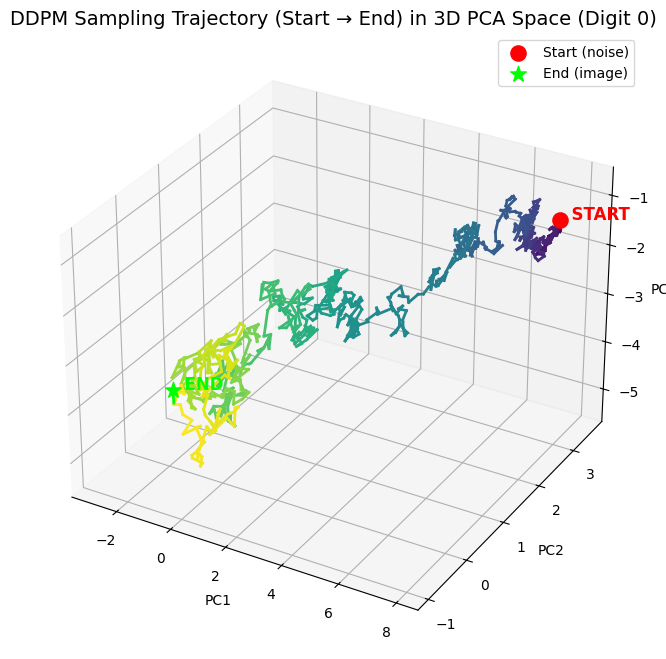

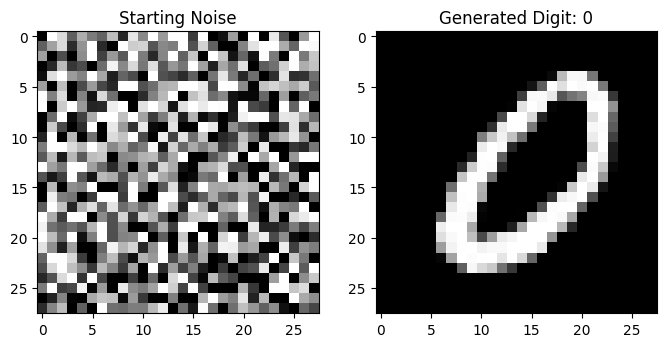

In [26]:
# inference
# What it does:
#   1) find a 3 coordinate system based on the traing data (here ground truth dist of zero images)
#   2) Runs DDPM sampling from gaussian noise
#   3) At each t, record x_t projected to onto 3d coordinate system
# -------------------------------

import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import matplotlib.cm as cm

# seed
np.random.seed(200)

# fit 3pca on training data
pca3 = PCA(n_components=3, random_state=0)
pca3.fit(zero_matrix)  # zero_matrix: (N,784)

# For projecting vectors WITHOUT mean shift:
P = pca3.components_.T  # (784,3)

# ddpm sampling
model.eval()

# specify digit to get (for now we just use one digit which is zero)
target_digit = 0

# start from x_T ~ N(0, I)
x_t = np.random.randn(784).astype(np.float32)
starting_noise = x_t.copy()

# create digit label (not necessary for only one digit)
digit_label = torch.tensor([target_digit], dtype=torch.long, device=device)  # (1,)

traj_xt = []       # x_t projected (mean-shifted PCA)
traj_det = []      # deterministic update projected (no mean shift)
traj_noise = []    # noise term projected (no mean shift)
ts = []

with torch.no_grad():
    for t in range(T, 0, -1):
        # tensors
        x_t_tensor = torch.tensor(x_t, dtype=torch.float32, device=device).unsqueeze(0)  # (1,784)
        t_norm = t / T
        t_tensor = torch.tensor([t_norm], dtype=torch.float32, device=device)            # (1,)

        # predict epsilon (now with digit label)
        eps_pred = model(x_t_tensor, t_tensor, digit_label).squeeze(0).cpu().numpy().astype(np.float32)  # (784,)

        # coefficients
        bt = float(beta_dict[t])
        sqrt_at = float(sqrt_alpha_dict[t])
        sqrt_one_minus_abar = float(sqrt_one_minus_alpha_bar_dict[t])

        # DDPM mean: mu_theta(x_t,t)
        mu = (1.0 / sqrt_at) * (x_t - (bt / sqrt_one_minus_abar) * eps_pred)  # (784,)

        # split into deterministic and stochastic parts
        det_step = (mu - x_t)  # (784,)
        if t > 1:
            z = np.random.randn(784).astype(np.float32)
            sigma = np.sqrt(bt).astype(np.float32)
            noise_step = sigma * z
            x_next = mu + noise_step
        else:
            noise_step = np.zeros_like(x_t)
            x_next = mu

        # project onto pca 3d coordinate system
        # state projection (includes PCA mean shift)
        xt_3d = pca3.transform(x_t[None, :])[0]  # (3,)

        # vector projections WITHOUT mean shift (recommended for steps)
        det_3d = det_step @ P        # (3,)
        noise_3d = noise_step @ P    # (3,)

        traj_xt.append(xt_3d)
        traj_det.append(det_3d)
        traj_noise.append(noise_3d)
        ts.append(t)

        # advance
        x_t = x_next

traj_xt = np.array(traj_xt)        # (T,3)
traj_det = np.array(traj_det)      # (T,3)
traj_noise = np.array(traj_noise)  # (T,3)
ts = np.array(ts)                  # (T,)

# reorder so plot runs from 1 -> T (increasing)
order = np.argsort(ts)
traj_xt = traj_xt[order]
traj_det = traj_det[order]
traj_noise = traj_noise[order]
ts = ts[order]

# plot 3d traj
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(traj_xt[:, 0], traj_xt[:, 1], traj_xt[:, 2], linewidth=2)

# mark start/end
ax.scatter(traj_xt[0, 0], traj_xt[0, 1], traj_xt[0, 2], s=60, marker='o')
ax.scatter(traj_xt[-1, 0], traj_xt[-1, 1], traj_xt[-1, 2], s=60, marker='^')

ax.set_title(f"DDPM Sampling Trajectory in 3D PCA Space (Digit {target_digit})")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

# arrows
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Color path by timestep (early = dark, late = bright)
colors = cm.viridis(np.linspace(0, 1, len(traj_xt)))

for i in range(len(traj_xt) - 1):
    ax.plot(
        traj_xt[i:i+2, 0],
        traj_xt[i:i+2, 1],
        traj_xt[i:i+2, 2],
        color=colors[i],
        linewidth=2
    )

# --- START point (x_T) ---
ax.scatter(
    traj_xt[0, 0], traj_xt[0, 1], traj_xt[0, 2],
    color='red', s=120, marker='o', label='Start (noise)'
)
ax.text(
    traj_xt[0, 0], traj_xt[0, 1], traj_xt[0, 2],
    '  START', color='red', fontsize=12, weight='bold'
)

# --- END point (x_0) ---
ax.scatter(
    traj_xt[-1, 0], traj_xt[-1, 1], traj_xt[-1, 2],
    color='lime', s=140, marker='*', label='End (image)'
)
ax.text(
    traj_xt[-1, 0], traj_xt[-1, 1], traj_xt[-1, 2],
    '  END', color='lime', fontsize=12, weight='bold'
)

# --- Direction arrows (first + last few steps only) ---
arrow_scale = 1.5

# near start
ax.quiver(
    traj_xt[0,0], traj_xt[0,1], traj_xt[0,2],
    traj_xt[3,0]-traj_xt[0,0],
    traj_xt[3,1]-traj_xt[0,1],
    traj_xt[3,2]-traj_xt[0,2],
    color='red', linewidth=2, arrow_length_ratio=0.2
)

# near end
ax.quiver(
    traj_xt[-4,0], traj_xt[-4,1], traj_xt[-4,2],
    traj_xt[-1,0]-traj_xt[-4,0],
    traj_xt[-1,1]-traj_xt[-4,1],
    traj_xt[-1,2]-traj_xt[-4,2],
    color='lime', linewidth=2, arrow_length_ratio=0.2
)

ax.set_title(f"DDPM Sampling Trajectory (Start → End) in 3D PCA Space (Digit {target_digit})", fontsize=14)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.show()

# show the final image
# rehsape and transform for visualization
denoised_image = x_t.reshape(28, 28)
starting_noise_img = starting_noise.reshape(28, 28)
denoised_image_viz = (denoised_image + 1.0) / 2.0
starting_noise_img_viz = (starting_noise_img + 1.0) / 2.0

# Visualize the result
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(starting_noise_img_viz, cmap='gray', vmin=0, vmax=1)
plt.title('Starting Noise')
plt.subplot(1, 2, 2)
plt.imshow(denoised_image_viz, cmap='gray', vmin=0, vmax=1)
plt.title(f'Generated Digit: {target_digit}')
plt.show()
